#   Data analysis

##  Import library

In [1]:
import os
import kagglehub
import shutil
import pandas as pd

##  Init data

In [ ]:
class Dataset:
    def __init__(self):
        self.destination = r"D:\CDNC\MIND-research\data\primary\dev_set"
        
        self.news_path = os.path.join(self.destination, "news.tsv")
        self.news_columns = [
            "News_ID",
            "Category",
            "SubCategory",
            "Title",
            "Abstract",
            "URL",
            "Title_Entities",
            "Abstract_Entities",
        ]
        
        self.behaviours_path = os.path.join(self.destination, "behaviors.tsv")
        self.behaviours_columns = [
            "user_id",
            "time",
            "history",
            "impressions"
        ]
        
    def getNewsData(self):
        self.newsData = pd.read_csv(
            self.news_path,
            sep="\t",
            names = self.news_columns
        )
        
        print("Got news dataset !! \n")
        display(self.newsData.head())
        # self.newsData.head().to_html("news_sample.html")
        return self.newsData
    
    def anaNewsData(self):
        if not hasattr(self, "newsData"):
            self.getNewsData()

        stats = {
            "Number of news articles": len(self.newsData),
            "Number of categories": self.newsData["Category"].nunique(),
            "Number of subcategories": self.newsData["SubCategory"].nunique(),
            "Number of missing values": self.newsData.isnull().sum().sum(),
            "Number of duplicate News_ID": self.newsData["News_ID"].duplicated().sum(),
        }

        stats_df = pd.DataFrame(
            stats.items(),
            columns=["Statistic", "Value"]
        )

        print("News Dataset Statistics\n")
        display(stats_df)

        # stats_df.to_html("news_statistics.html", index=False)

        return stats_df
        
    
    def getBehavioursData(self):
        self.behavioursData = pd.read_csv(
            self.behaviours_path,
            sep="\t",
            names=self.behaviours_columns
        )
        
        print("Got behaviours dataset !! \n")
        display(self.behavioursData.head())
        # self.behavioursData.head().to_html("behaviours_sample.html")
        return self.behavioursData
    
    def anaBehavioursData(self):
        if not hasattr(self, "behavioursData"):
            self.getBehavioursData()

        stats = {
            "Number of behaviour records": len(self.behavioursData),
            "Number of unique users": self.behavioursData["user_id"].nunique(),
            "Number of missing values": self.behavioursData.isnull().sum().sum(),
            "Number of duplicate records": self.behavioursData.duplicated().sum(),
        }

        stats_df = pd.DataFrame(
            stats.items(),
            columns=["Statistic", "Value"]
        )

        print("Behaviours Dataset Statistics\n")
        display(stats_df)

        # stats_df.to_html("behaviours_statistics.html", index=False)

        return stats_df
    

In [8]:
ds = Dataset()
news_ds = ds.getNewsData()
print("------------------------")

ds.anaNewsData()

Got news dataset !! 



,News_ID,Category,SubCategory,Title,Abstract,URL,Title_Entities,Abstract_Entities
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N23144,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N86255,health,medical,Dispose of unwanted prescription drugs during ...,NaN,https://assets.msn.com/labs/mind/AAISxPN.html,"[{""Label"": ""Drug Enforcement Administration"", ...",[]
3,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
4,N75236,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."


------------------------
News Dataset Statistics



,Statistic,Value
0,Number of news articles,72023
1,Number of categories,17
2,Number of subcategories,269
3,Number of missing values,3630
4,Number of duplicate News_ID,0


,Statistic,Value
0,Number of news articles,72023
1,Number of categories,17
2,Number of subcategories,269
3,Number of missing values,3630
4,Number of duplicate News_ID,0


In [9]:
behaviours_ds = ds.getBehavioursData()

ds.anaBehavioursData()

Got behaviours dataset !! 



,user_id,time,history,impressions
1,U134050,11/15/2019 8:55:22 AM,N12246 N128820 N119226 N4065 N67770 N33446 N10...,N91737-0 N30206-0 N54368-0 N117802-0 N18190-0 ...
2,U254959,11/15/2019 11:42:35 AM,N34011 N9375 N67397 N7936 N118985 N109453 N103...,N119999-0 N24958-0 N104054-0 N33901-0 N9250-0 ...
3,U499841,11/15/2019 9:08:21 AM,N63858 N26834 N6379 N85484 N15229 N65119 N1047...,N18190-0 N89764-0 N91737-0 N54368-0 N49978-1 N...
4,U107107,11/15/2019 5:50:31 AM,N12959 N8085 N18389 N3758 N9740 N90543 N129790...,N122944-1 N18190-0 N55801-0 N59297-0 N128045-0...
5,U492344,11/15/2019 5:02:25 AM,N109183 N48453 N85005 N45706 N98923 N46069 N35...,N64785-0 N82503-0 N32993-0 N122944-0 N29160-0 ...


Behaviours Dataset Statistics



,Statistic,Value
0,Number of behaviour records,376471
1,Number of unique users,255990
2,Number of missing values,11270
3,Number of duplicate records,0


,Statistic,Value
0,Number of behaviour records,376471
1,Number of unique users,255990
2,Number of missing values,11270
3,Number of duplicate records,0


##  Compare train, dev, and test sets

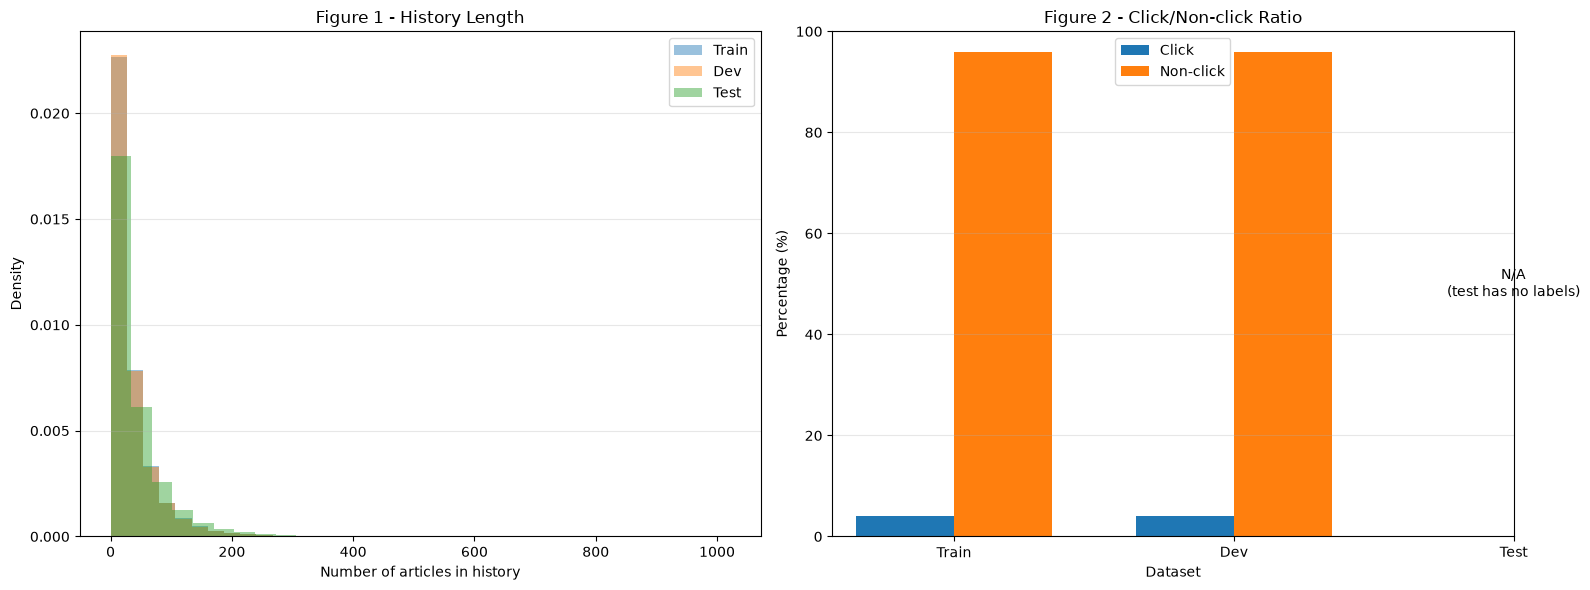

In [10]:
import matplotlib.pyplot as plt
import numpy as np

base_path = r"D:\CDNC\MIND-research\data\primary"
set_names = ["train", "dev", "test"]

behaviour_sets = {}
for set_name in set_names:
    behaviour_path = os.path.join(base_path, f"{set_name}_set", "behaviors.tsv")
    behaviour_sets[set_name] = pd.read_csv(
        behaviour_path,
        sep="\t",
        names=["user_id", "time", "history", "impressions"]
    )

history_lengths = {
    set_name: data["history"].fillna("").str.split().str.len()
    for set_name, data in behaviour_sets.items()
}

click_ratios = {}
for set_name, data in behaviour_sets.items():
    labels = data["impressions"].fillna("").str.findall(r"-(0|1)(?:\s|$)").explode()
    label_counts = labels.value_counts().reindex(["1", "0"], fill_value=0)
    total_labels = label_counts.sum()
    click_ratios[set_name] = {
        "Click": label_counts["1"] / total_labels * 100 if total_labels else np.nan,
        "Non-click": label_counts["0"] / total_labels * 100 if total_labels else np.nan,
    }

ratio_df = pd.DataFrame(click_ratios).T
ratio_df

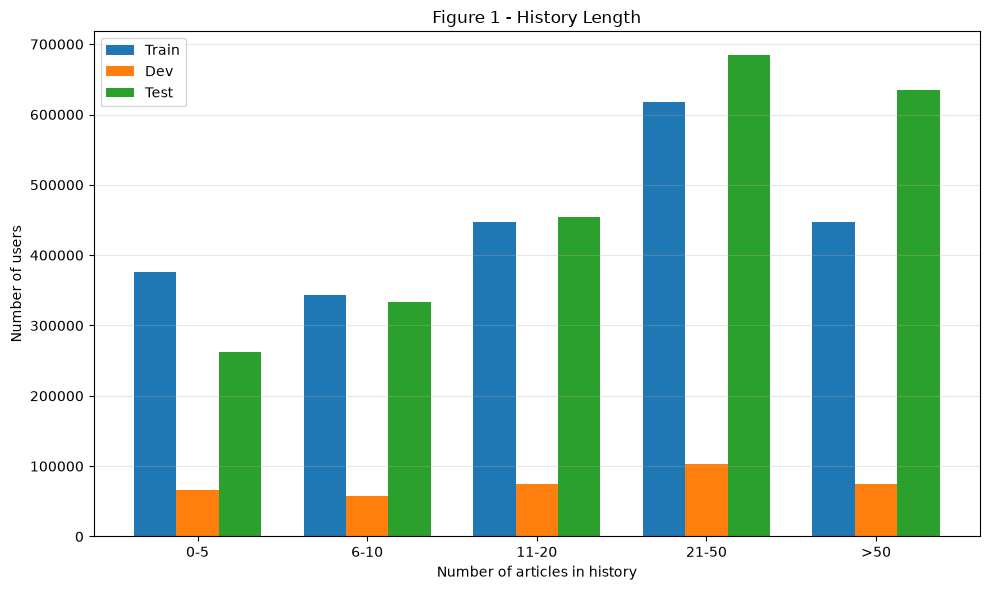

In [14]:
history_bins = [-1, 5, 10, 20, 50, float("inf")]
history_labels = ["0-5", "6-10", "11-20", "21-50", ">50"]

history_length_counts = pd.DataFrame({
    set_name: pd.cut(
        history_lengths[set_name],
        bins=history_bins,
        labels=history_labels
    ).value_counts().reindex(history_labels, fill_value=0)
    for set_name in set_names
})

plt.figure(figsize=(10, 6))

x_positions = np.arange(len(history_labels))
bar_width = 0.25

for index, set_name in enumerate(set_names):
    plt.bar(
        x_positions + (index - 1) * bar_width,
        history_length_counts[set_name],
        bar_width,
        label=set_name.capitalize()
    )

plt.title("Figure 1 - History Length")
plt.xlabel("Number of articles in history")
plt.ylabel("Number of users")
plt.xticks(x_positions, history_labels)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

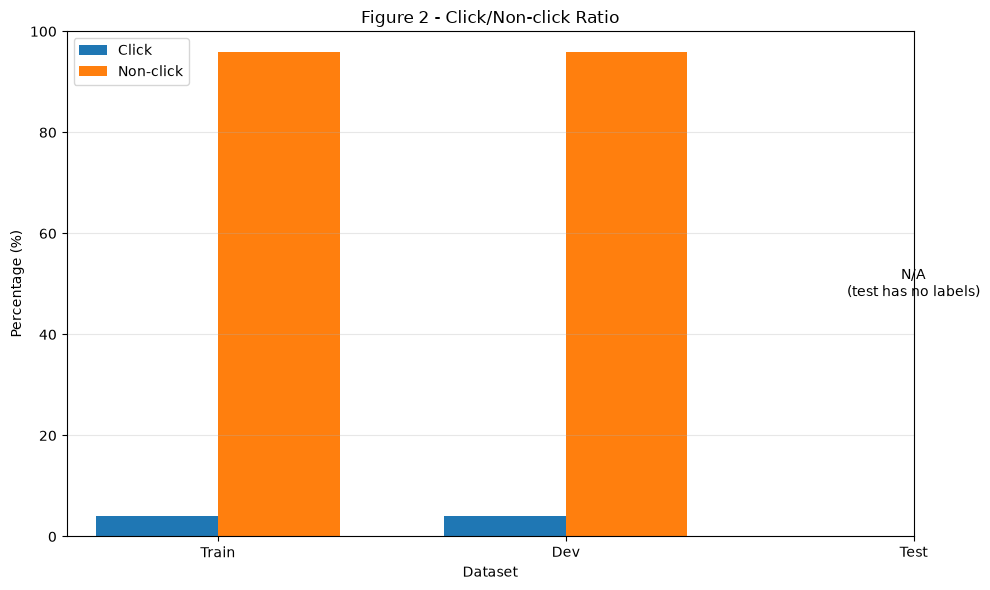

In [12]:
plt.figure(figsize=(10, 6))

x_positions = np.arange(len(set_names))
bar_width = 0.35

plt.bar(
    x_positions - bar_width / 2,
    ratio_df["Click"],
    bar_width,
    label="Click"
)
plt.bar(
    x_positions + bar_width / 2,
    ratio_df["Non-click"],
    bar_width,
    label="Non-click"
)

plt.title("Figure 2 - Click/Non-click Ratio")
plt.xlabel("Dataset")
plt.ylabel("Percentage (%)")
plt.xticks(x_positions, [set_name.capitalize() for set_name in set_names])
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)

if ratio_df.loc["test"].isna().all():
    plt.text(
        x_positions[-1],
        50,
        "N/A\n(test has no labels)",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()